# Naive Bayes Algorithm

### For Today's session, we will be looking over Naive Bayes algorithm for classification task.


**Naïve Bayes:** For the given features (x) and the label y, it estimates a joint probability from the training data. Hence this is a Generative model

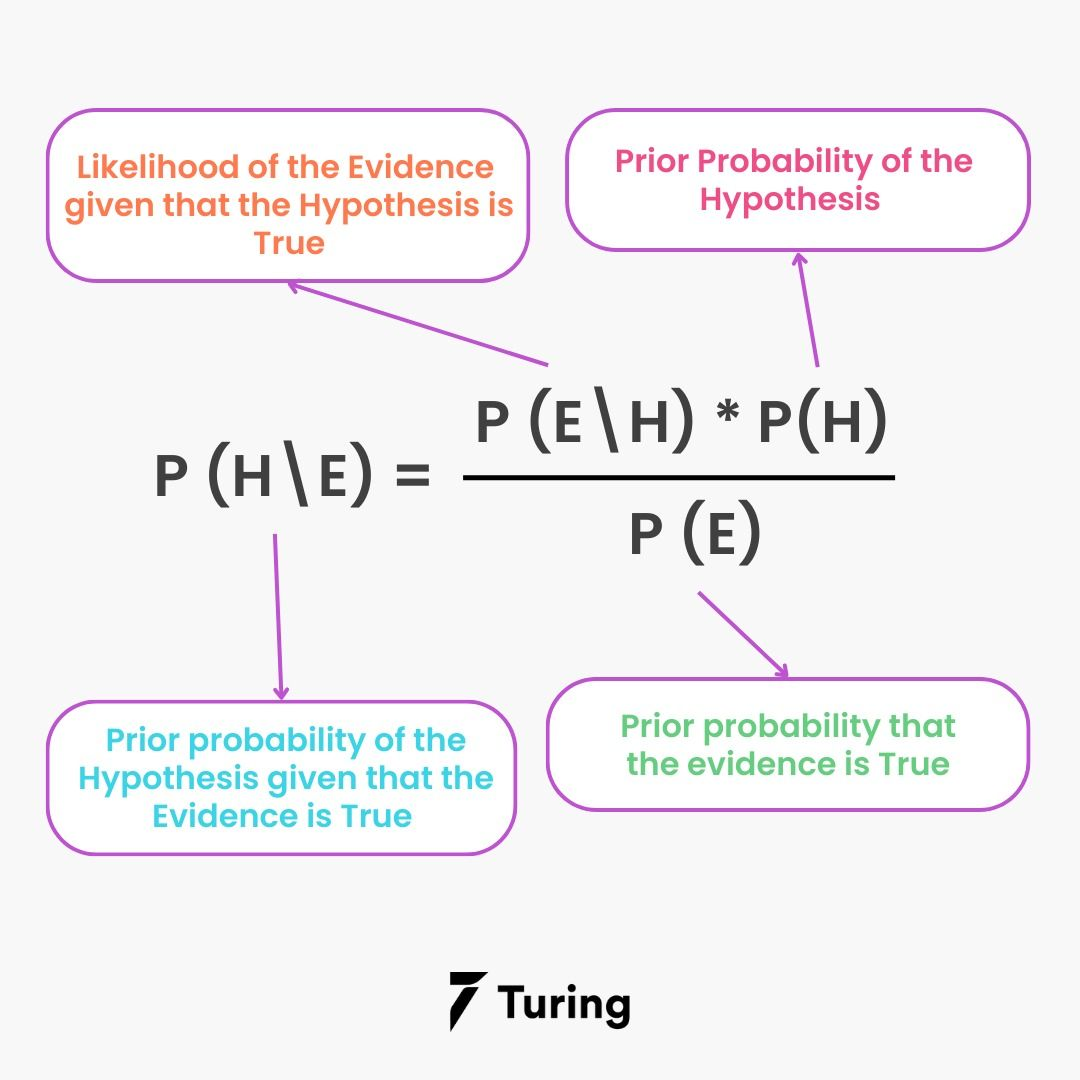

## Properties of Naive Bayes

1. This is a Generative model.
2. The model assumes all the features are conditionally independent .so, if some of the features are dependent on each other (in case of a large feature space), the prediction might be poor.
3. Works well even with less training data, as the estimates are based on the joint density function.
4. When the training data size is less relative to the features, the information/data on prior probabilities help in improving the results.

5. You set each feature's weight independently, based on how much it correlates with the label. (Weights come out to be the features' log-likelihood ratios for the different classes.)

## How to apply Naive Bayes



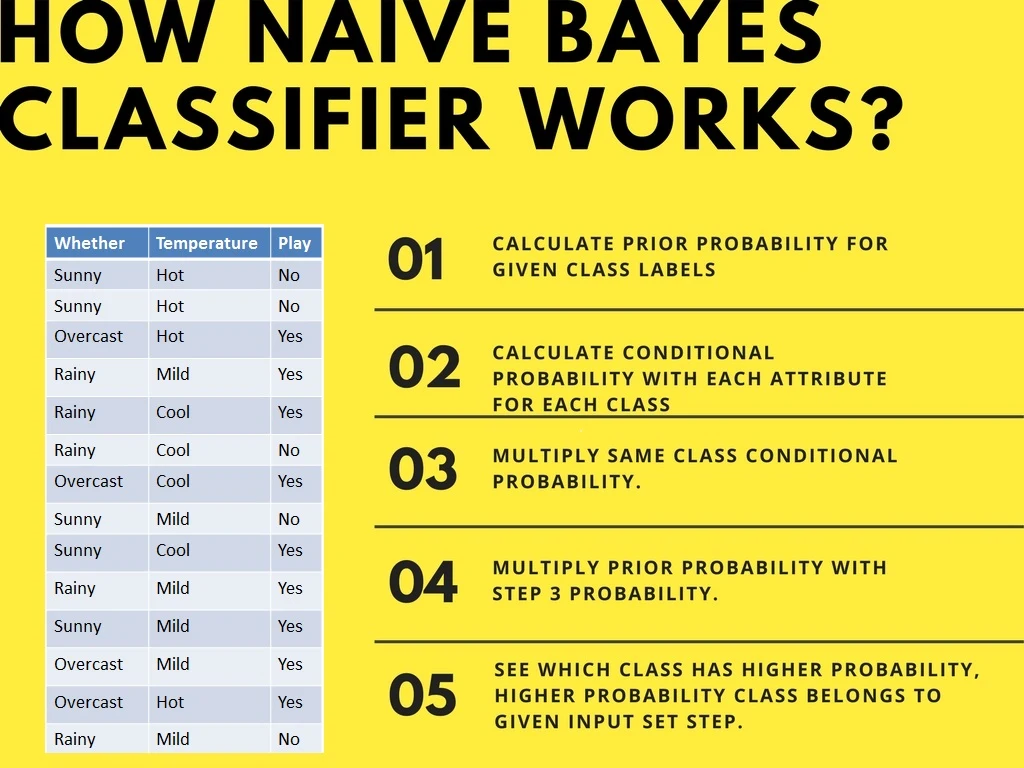

* Suppose you want to calculate the probability of **playing when the weather is overcast, and the temperature is mild.**

Probability of playing:

1. Calculate Prior Probabilities: **P(Yes)= 9/14 = 0.64**
2. Calculate Posterior Probabilities: **P(Overcast |Yes) = 4/9 = 0.44**, **P(Mild |Yes) = 4/9 = 0.44**
3. Put Posterior probabilities in equation **P(Weather=Overcast, Temp=Mild | Play= Yes) = 0.44 * 0.44 = 0.1936**
4. Put Prior and Posterior probabilities in equation **P(Play= Yes | Weather=Overcast, Temp=Mild) = 0.1936*0.64 = 0.124**

Similarly, you can calculate the probability of not playing:

Probability of not playing:

1. Calculate Prior Probabilities: **P(No)= 5/14 = 0.36**
2. Calculate Posterior Probabilities:**P(Weather=Overcast |Play=No) = 0/9 = 0**, **P(Temp=Mild | Play=No)=2/5=0.4**
3. Put posterior probabilities in equation **P(Weather=Overcast, Temp=Mild | Play= No) = 0 * 0.4= 0**
4. Put prior and posterior probabilities in equation **P(Play= No | Weather=Overcast, Temp=Mild) = 0*0.36=0**

The probability of a 'Yes' class is higher (obviously). So you can say here that if the weather is overcast, than players will play the sport.

## Implementation from scratch

In [89]:
import math
import random
import csv

In [100]:
classes = []

# encode the sample data 
def encode_class(mydata):
    
    # add any new class
    for i in range(len(mydata)):
        if mydata[i][-1] not in classes:
            classes.append(mydata[i][-1])
    # add data points
    for i in range(len(classes)):
        for j in range(len(mydata)):
            if mydata[j][-1] == classes[i]:
                mydata[j][-1] = i
    print("There are total of", len(classes), "classes, which are ", classes)
    return mydata   


In [101]:
# add the data path in your system

filename = r'datasets/sample_data.csv'
 
 
# load the file and store it in mydata list
mydata = csv.reader(open(filename, "rt"))
mydata = list(mydata)
mydata = encode_class(mydata)
for i in range(len(mydata)):
    mydata[i] = [float(x) for x in mydata[i]]

print(mydata[0:2])

There are total of 2 classes, which are  ['ClassA', 'ClassB']
[[6.0, 148.0, 72.0, 35.0, 0.0, 33.6, 0.627, 50.0, 0.0], [1.0, 85.0, 66.0, 29.0, 0.0, 26.6, 0.351, 31.0, 1.0]]


In [102]:
# Splitting the data
def splitting(mydata, ratio):
    train_num = int(len(mydata) * ratio)
    train = []
    # initially testset will have all the dataset
    test = list(mydata)
    while len(train) < train_num:
        # index generated randomly from range 0
        # to length of testset
        index = random.randrange(len(test))
        # from testset, pop data rows and put it in train
        train.append(test.pop(index))
    return train, test

ratio = 0.7
train_data, test_data = splitting(mydata, ratio)

print(len(mydata))
print(len(train_data))
print(len(test_data))



768
537
231


In [103]:
# Group the data rows under each class yes or
# no in dictionary eg: dict[yes] and dict[no]
def groupUnderClass(mydata):
      dict = {}
      for i in range(len(mydata)):
          if (mydata[i][-1] not in dict):
              dict[mydata[i][-1]] = []
          dict[mydata[i][-1]].append(mydata[i])
      return dict

data_dict = groupUnderClass(mydata)

print(len(data_dict[0]))
print(len(data_dict[1]))
 

268
500


*Gaussian Probability Density Function*

![gaussian pdf.png](<attachment:gaussian pdf.png>)
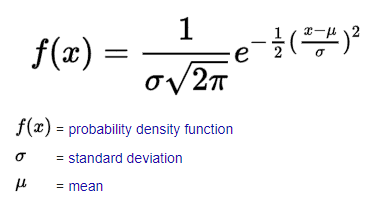

In [104]:
# Calculating Mean
def mean(numbers):
    return sum(numbers) / float(len(numbers))
 
# Calculating Standard Deviation
def std_dev(numbers):
    avg = mean(numbers)
    variance = sum([pow(x - avg, 2) for x in numbers]) / float(len(numbers) - 1 + 0.01)
    return math.sqrt(variance)
 

In [105]:
def MeanAndStdDev(mydata):
    info = [(mean(attribute), std_dev(attribute)) for attribute in zip(*mydata)]
    # eg: list = [ [a, b, c], [m, n, o], [x, y, z]]
    # here mean of 1st attribute =(a + m+x), mean of 2nd attribute = (b + n+y)/3
    # delete summaries of last class
    del info[-1]
    return info
 
# find Mean and Standard Deviation under each class
def MeanAndStdDevForClass(mydata):
    info = {}
    dict = groupUnderClass(mydata)
    for classValue, instances in dict.items():
        info[classValue] = MeanAndStdDev(instances)
    return info


info = MeanAndStdDevForClass(train_data)

info

{0.0: [(4.672043010752688, 3.7437186812191983),
  (142.91935483870967, 29.06426644214902),
  (72.10215053763442, 20.813811292008754),
  (22.580645161290324, 18.139400142679595),
  (100.74731182795699, 148.35627365953772),
  (35.82741935483872, 6.73478127757437),
  (0.5472903225806457, 0.38941736009677547),
  (36.983870967741936, 11.152434674172467)],
 1.0: [(3.2735042735042734, 2.918736712788896),
  (109.24501424501425, 25.662554327156073),
  (69.06552706552706, 17.215651441219528),
  (19.59259259259259, 15.036952544726269),
  (69.03703703703704, 101.26502671508153),
  (30.557549857549876, 7.333391284606552),
  (0.42702279202279225, 0.3051285105543204),
  (31.09116809116809, 11.22418597717499)]}

In [106]:
# Calculate Gaussian Probability Density Function
def calculateGaussianProbability(x, mean, stdev):
    expo = math.exp(-(math.pow(x - mean, 2) / (2 * math.pow(stdev, 2))))
    return (1 / (math.sqrt(2 * math.pi) * stdev)) * expo
 
 
# Calculate Class Probabilities
def calculateClassProbabilities(info, test):
    probabilities = {}
    for classValue, classSummaries in info.items():
        probabilities[classValue] = 1
        for i in range(len(classSummaries)):
            mean, std_dev = classSummaries[i]
            x = test[i]
            probabilities[classValue] *= calculateGaussianProbability(x, mean, std_dev)
    return probabilities

print(calculateClassProbabilities(info, [0,118,84,47,230,45.8,0.551,31]))


{0.0: 7.770346374509225e-14, 1.0: 2.561334375061546e-14}


In [107]:
# Make prediction - highest probability is the prediction
def predict(info, test):
    probabilities = calculateClassProbabilities(info, test)
    bestLabel, bestProb = None, -1
    for classValue, probability in probabilities.items():
        if bestLabel is None or probability > bestProb:
            bestProb = probability
            bestLabel = classValue
    return bestLabel

In [112]:
# returns predictions for a set of examples
def getPredictions(info, test):
    predictions = []
    for i in range(len(test)):
        result = predict(info, test[i])
        predictions.append(result)
    return predictions
 
# Accuracy score
def accuracy_rate(test, predictions):
    correct = 0
    for i in range(len(test)):
        if test[i][-1] == predictions[i]:
            correct += 1
    return (correct / float(len(test))) * 100.0

print(getPredictions(info, [[0,118,84,47,230,45.8,0.551,31], [8,99,84,0,0,35.4,0.388,50]]))

[0.0, 0.0]


In [113]:
classes

['ClassA', 'ClassB']

In [109]:
# split ratio = 0.7
# 70% of data is training data and 30% is test data used for testing
ratio = 0.7
train_data, test_data = splitting(mydata, ratio)
print('Total number of examples are: ', len(mydata))
print('Out of these, training examples are: ', len(train_data))
print("Test examples are: ", len(test_data))
 
# prepare model
info = MeanAndStdDevForClass(train_data)
 
# test model
predictions = getPredictions(info, test_data)
accuracy = accuracy_rate(test_data, predictions)
print("Accuracy of your model is: ", accuracy)

Total number of examples are:  768
Out of these, training examples are:  537
Test examples are:  231
Accuracy of your model is:  68.3982683982684


## Implementation from sklearn on Loan Data

In [ ]:
import pandas as pd


df = pd.read_csv('datasets/loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


Here are what the columns represent:

1. **credit.policy:** 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
2. **purpose:** The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
3. **int.rate:** The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
4. **installment:** The monthly installments owed by the borrower if the loan is funded.
5. **log.annual.inc:** The natural log of the self-reported annual income of the borrower.
6. **dti:** The debt-to-income ratio of the borrower (amount of debt divided by annual income).
7. **fico:** The FICO credit score of the borrower.
8. **days.with.cr.line:** The number of days the borrower has had a credit line.
9. **revol.bal:** The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
10. **revol.util:** The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
11. **inq.last.6mths:** The borrower's number of inquiries by creditors in the last 6 months.
12. **delinq.2yrs:** The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
13. **pub.rec:** The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


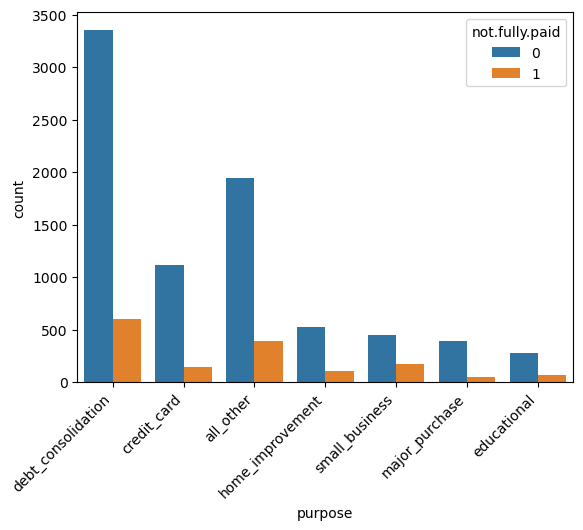

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df,x='purpose',hue='not.fully.paid')
plt.xticks(rotation=45, ha='right');

In [ ]:
pre_df = pd.get_dummies(df,columns=['purpose'],drop_first=True)
pre_df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X = pre_df.drop('not.fully.paid', axis=1)
y = pre_df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=125
)

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train);

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
)

y_pred = model.predict(X_test)

accuray = accuracy_score(y_pred, y_test)
f1 = f1_score(y_pred, y_test, average="weighted")

print("Accuracy:", accuray)
print("F1 Score:", f1)

Accuracy: 0.8206263840556786
F1 Score: 0.8686606980013266


In [ ]:
y_test

5693    0
9569    1
1539    1
3596    0
7931    0
       ..
6612    0
594     0
8270    0
4646    1
6968    0
Name: not.fully.paid, Length: 3161, dtype: int64

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

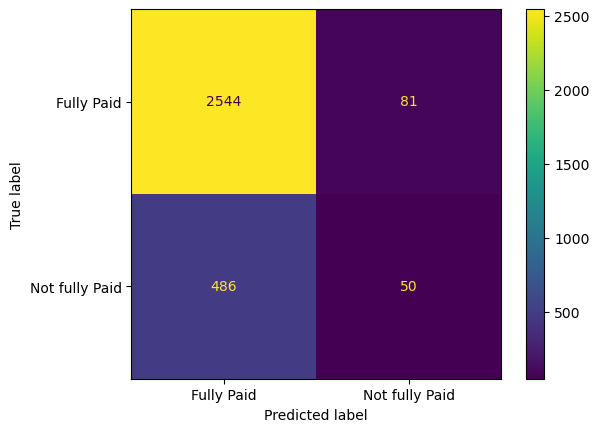

In [ ]:
labels = ["Fully Paid", "Not fully Paid"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();

## Resources

1. [StatQuest, Naive Bayes](https://youtube.com/watch?v=O2L2Uv9pdDA)
2. [Naive Bayes Classifier From Scratch in Python](https://machinelearningmastery.com/naive-bayes-classifier-scratch-python/)
3. [Naive Bayes Classification Tutorial using Scikit-learn](https://www.datacamp.com/tutorial/naive-bayes-scikit-learn)